# ABSA Training, Evaluation, Saving, and Streamlit Inference


## 1. Imports and Environment Setup


In [68]:
from __future__ import annotations

import gc
import json
import os
import random
import re
import shutil
import sys
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from tqdm.auto import tqdm

try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
    HAS_ITERSTRAT = True
except Exception:
    HAS_ITERSTRAT = False

import torch
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 180)

print("Python:", sys.executable)
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))


Python: c:\diploma1\.venv\Scripts\python.exe
torch: 2.5.1+cu121
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3060 Laptop GPU


## 2. Global Configuration


In [ ]:
PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "dataset_reviews.xlsx"
DATA_SHEET = "Data"
OUTPUT_DIR = PROJECT_DIR / "models" / "final_model"

SEED = 42

ASPECT_SCHEMA = [
    ("FQ", "Food Quality"),
    ("SS", "Staff Service"),
    ("OA", "Order Accuracy"),
    ("CL", "Cleanliness/Hygiene"),
    ("PV", "Price/Value"),
    ("WS", "Wait/Speed"),
    ("AM", "Ambience"),
    ("LO", "Location"),
]
ASPECT_CODES = [code for code, _ in ASPECT_SCHEMA]
ASPECT_NAME_MAP = dict(ASPECT_SCHEMA)
SENTIMENT_ORDER = ["negative", "neutral", "positive"]
VALID_SENTIMENTS = set(SENTIMENT_ORDER)


CHECKPOINT = "xlm-roberta-large"
OUTPUT_DIR_RUBERT = PROJECT_DIR / "models" / "final_model_rubert"
RUBERT_CHECKPOINT = "DeepPavlov/rubert-base-cased"

TRANSFORMER_EPOCHS = 6
EARLY_STOPPING_PATIENCE = 2
EARLY_STOPPING_MIN_DELTA = 1e-4
WARMUP_RATIO = 0.06
WEIGHT_DECAY = 0.01
SAMPLE_LIMIT = None
OVERWRITE_OUTPUT = True
RUN_BASELINES = True
RUN_TRANSFORMER_TRAINING = True
RUN_RUBERT_TRAINING = True


RUN_XLMR_HYPERPARAMETER_TUNING = False
XLMR_TUNING_EPOCHS = 3
XLMR_TUNING_PATIENCE = 1
XLMR_TUNING_SAMPLE_LIMIT = None
XLMR_TUNING_TASKS = ["aspect", "sentiment"]

CHECKPOINT_PRESETS = {
    "xlm-roberta-large": {
        "batch_size": 1,
        "max_length": 128,
        "grad_accum_steps": 4,
        "learning_rate": 1e-5,
        "gradient_checkpointing": True,
        "freeze_encoder_layers": 12,
    },
    "DeepPavlov/rubert-base-cased": {
        "batch_size": 2,
        "max_length": 192,
        "grad_accum_steps": 4,
        "learning_rate": 2e-5,
        "gradient_checkpointing": False,
        "freeze_encoder_layers": 0,
    },
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PRESET = CHECKPOINT_PRESETS.get(CHECKPOINT, CHECKPOINT_PRESETS["DeepPavlov/rubert-base-cased"])

print("Project directory:", PROJECT_DIR)
print("Dataset path:", DATA_PATH)
print("Checkpoint:", CHECKPOINT)
print("Output directory:", OUTPUT_DIR)
print("RuBERT checkpoint:", RUBERT_CHECKPOINT)
print("RuBERT output directory:", OUTPUT_DIR_RUBERT)
print("Device:", DEVICE)
print("Preset:", PRESET)


Project directory: c:\diploma1
Dataset path: c:\diploma1\dataset_reviews.xlsx
Checkpoint: xlm-roberta-large
Output directory: c:\diploma1\models\final_model
RuBERT checkpoint: DeepPavlov/rubert-base-cased
RuBERT output directory: c:\diploma1\models\final_model_rubert
Device: cuda
Preset: {'batch_size': 1, 'max_length': 128, 'grad_accum_steps': 4, 'learning_rate': 1e-05, 'gradient_checkpointing': True, 'freeze_encoder_layers': 12}


## 3. Reproducibility


In [70]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

## 4. Schema Inference and Preprocessing Helpers


In [71]:
COLUMN_CANDIDATES = {
    "review_id": ["review_id", "id", "reviewid", "review_no"],
    "text": ["text", "review_text", "review", "comment", "body", "message"],
    "rating": ["star_rating", "rating", "stars", "score", "grade"],
    "language": ["language", "lang", "detected_language"],
}

ASPECT_COLUMN_CANDIDATES = {
    "FQ": ["FQ", "food_quality", "food", "taste", "quality_food"],
    "SS": ["SS", "staff_service", "service", "staff"],
    "OA": ["OA", "order_accuracy", "order"],
    "CL": ["CL", "cleanliness", "hygiene", "clean"],
    "PV": ["PV", "price_value", "price", "value"],
    "WS": ["WS", "wait_speed", "speed", "wait"],
    "AM": ["AM", "ambience", "atmosphere", "interior"],
    "LO": ["LO", "location", "place_location"],
}

def normalize_column_name(name: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(name).strip().lower())

def infer_column(columns: list[str], candidates: list[str]) -> str | None:
    normalized = {normalize_column_name(col): col for col in columns}
    for candidate in candidates:
        exact = normalized.get(normalize_column_name(candidate))
        if exact is not None:
            return exact
    for col in columns:
        col_norm = normalize_column_name(col)
        if any(normalize_column_name(candidate) in col_norm for candidate in candidates):
            return col
    return None

def infer_sentiment_column(columns: list[str], aspect_code: str) -> str | None:
    candidates = [
        f"{aspect_code}_sent",
        f"{aspect_code}_sentiment",
        f"{aspect_code.lower()}_sent",
        f"{aspect_code.lower()}_sentiment",
    ]
    found = infer_column(columns, candidates)
    if found:
        return found
    aspect_norm = normalize_column_name(aspect_code)
    for col in columns:
        col_norm = normalize_column_name(col)
        if aspect_norm in col_norm and ("sent" in col_norm or "tone" in col_norm):
            return col
    return None

def clean_text(text: Any, lowercase: bool = True) -> str:
    if pd.isna(text):
        return ""
    text = str(text).replace("\u00a0", " ")
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r"([!?.,])\1{2,}", r"\1\1", text)
    return text.lower() if lowercase else text

def normalize_sentiment(value: Any) -> str | None:
    if pd.isna(value):
        return None
    text = str(value).strip().lower()
    mapping = {
        "-1": "negative",
        "0": "neutral",
        "1": "positive",
        "neg": "negative",
        "negative": "negative",
        "bad": "negative",
        "neutral": "neutral",
        "neu": "neutral",
        "positive": "positive",
        "pos": "positive",
        "good": "positive",
    }
    return mapping.get(text)

def detect_language_heuristic(text: str) -> str:
    kazakh_chars = set("әіңғүұқөһӘІҢҒҮҰҚӨҺ")
    cyrillic = re.findall(r"[А-Яа-яЁёӘәІіҢңҒғҮүҰұҚқӨөҺһ]", text)
    if not cyrillic:
        return "other"
    if any(ch in kazakh_chars for ch in text):
        return "kz"
    return "ru"

def format_sentiment_input(text: str, aspect_name: str) -> str:
    return f"Aspect: {aspect_name}. Review: {text}"

## 5. Data Loading and Label Preparation


In [72]:
def build_sentiment_rows(reviews: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in reviews.iterrows():
        for code, aspect_name in ASPECT_SCHEMA:
            sentiment = row.get(f"{code}_sentiment")
            if int(row[code]) == 1 and sentiment in VALID_SENTIMENTS:
                rows.append(
                    {
                        "review_id": row["review_id"],
                        "text_clean": row["text_clean"],
                        "aspect_code": code,
                        "aspect_name": aspect_name,
                        "sentiment": sentiment,
                        "model_text": format_sentiment_input(row["text_clean"], aspect_name),
                    }
                )
    return pd.DataFrame(rows)

def load_and_prepare_data(data_path: Path, sheet: str, sample_limit: int | None = None):
    raw = pd.read_excel(data_path, sheet_name=sheet)
    raw_row_count = len(raw)
    columns = [str(col) for col in raw.columns]

    text_col = infer_column(columns, COLUMN_CANDIDATES["text"])
    if not text_col:
        raise ValueError(f"Could not infer review text column. Available columns: {list(raw.columns)}")

    review_id_col = infer_column(columns, COLUMN_CANDIDATES["review_id"])
    rating_col = infer_column(columns, COLUMN_CANDIDATES["rating"])
    language_col = infer_column(columns, COLUMN_CANDIDATES["language"])

    prepared = pd.DataFrame()
    prepared["review_id"] = raw[review_id_col] if review_id_col else np.arange(1, len(raw) + 1)
    prepared["text"] = raw[text_col]
    prepared["text_clean"] = prepared["text"].map(clean_text)
    prepared["rating"] = raw[rating_col] if rating_col else np.nan
    prepared["language"] = raw[language_col] if language_col else prepared["text_clean"].map(detect_language_heuristic)

    column_mapping = {
        "review_id": review_id_col,
        "text": text_col,
        "rating": rating_col,
        "language": language_col,
        "aspects": {},
        "sentiments": {},
    }

    for code in ASPECT_CODES:
        aspect_col = infer_column(columns, ASPECT_COLUMN_CANDIDATES[code])
        if aspect_col is None:
            raise ValueError(f"Could not find aspect column for {code}.")
        sentiment_col = infer_sentiment_column(columns, code)
        prepared[code] = pd.to_numeric(raw[aspect_col], errors="coerce")
        prepared[f"{code}_sentiment"] = raw[sentiment_col].map(normalize_sentiment) if sentiment_col else None
        column_mapping["aspects"][code] = aspect_col
        column_mapping["sentiments"][code] = sentiment_col

    empty_text_rows = int((prepared["text_clean"].str.len() == 0).sum())
    prepared = prepared[prepared["text_clean"].str.len() > 0].copy()

    valid_aspect_mask = prepared[ASPECT_CODES].apply(lambda col: col.isin([0, 1])).all(axis=1)
    invalid_aspect_rows = int((~valid_aspect_mask).sum())
    prepared = prepared[valid_aspect_mask].copy()
    prepared[ASPECT_CODES] = prepared[ASPECT_CODES].astype(int)

    if sample_limit:
        prepared = prepared.sample(n=min(sample_limit, len(prepared)), random_state=SEED).copy()

    sentiment_rows = build_sentiment_rows(prepared)
    audit = {
        "raw_rows": int(raw_row_count),
        "usable_review_rows": int(len(prepared)),
        "dropped_empty_text_rows": empty_text_rows,
        "dropped_invalid_aspect_rows": invalid_aspect_rows,
        "aspect_positive_counts": prepared[ASPECT_CODES].sum().astype(int).to_dict(),
        "sentiment_rows": int(len(sentiment_rows)),
        "sentiment_distribution": sentiment_rows["sentiment"].value_counts().to_dict(),
        "language_distribution": prepared["language"].fillna("unknown").value_counts().to_dict(),
        "column_mapping": column_mapping,
    }
    return prepared.reset_index(drop=True), sentiment_rows.reset_index(drop=True), audit

reviews, sentiment_rows, audit = load_and_prepare_data(DATA_PATH, DATA_SHEET, SAMPLE_LIMIT)
display(Markdown("### Dataset Audit"))
display(pd.DataFrame([audit]).T.rename(columns={0: "value"}))
display(Markdown("### Example Reviews"))
display(reviews[["review_id", "language", "rating", "text_clean", *ASPECT_CODES]].head())

### Dataset Audit

,value
raw_rows,2377
usable_review_rows,2374
dropped_empty_text_rows,0
dropped_invalid_aspect_rows,3
aspect_positive_counts,"{'FQ': 1128, 'SS': 1094, 'OA': 354, 'CL': 398, 'PV': 299, 'WS': 356, 'AM': 582, 'LO': 274}"
sentiment_rows,4485
sentiment_distribution,"{'positive': 2113, 'negative': 1779, 'neutral': 593}"
language_distribution,"{'ru': 1061, 'kz': 1001, 'mixed': 312}"
column_mapping,"{'review_id': 'review_id', 'text': 'text', 'rating': 'star_rating', 'language': 'language', 'aspects': {'FQ': 'FQ', 'SS': 'SS', 'OA': 'OA', 'CL': 'CL', 'PV': 'PV', 'WS': 'WS', ..."


### Example Reviews

,review_id,language,rating,text_clean,FQ,SS,OA,CL,PV,WS,AM,LO
0,1,ru,4.0,"еда вкусная, персонал вежливый, но заказ ждали слишком долго.",1,1,0,0,0,1,0,0
1,2,ru,2.0,"в помещении грязно, заказ перепутали, а цена для такого качества завышена.",0,0,1,1,1,0,0,0
2,3,ru,5.0,"очень уютное место, удобная локация, кофе свежий и вкусный.",1,0,0,0,0,0,1,1
3,4,kz,3.0,"тағам жаман емес, бірақ қызмет баяу және офицанттар көңіл бөлмеді.",1,1,0,0,0,1,0,0
4,5,ru,5.0,"очень вкусные бургеры,всем советуюю",1,0,0,0,0,0,0,0


## 6. Train/Validation/Test Split


In [73]:
def multilabel_split(reviews: pd.DataFrame, seed: int, test_size: float = 0.15, val_size: float = 0.15):
    y = reviews[ASPECT_CODES].values
    indices = np.arange(len(reviews))
    if HAS_ITERSTRAT and len(reviews) >= 10:
        splitter = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        train_val_idx, test_idx = next(splitter.split(indices, y))
        val_relative_size = val_size / (1 - test_size)
        splitter_2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=val_relative_size, random_state=seed + 1)
        train_idx_rel, val_idx_rel = next(splitter_2.split(train_val_idx, y[train_val_idx]))
        train_idx = train_val_idx[train_idx_rel]
        val_idx = train_val_idx[val_idx_rel]
        strategy = "iterative_multilabel_stratification"
    else:
        from sklearn.model_selection import train_test_split
        train_val_idx, test_idx = train_test_split(indices, test_size=test_size, random_state=seed, shuffle=True)
        train_idx, val_idx = train_test_split(train_val_idx, test_size=val_size / (1 - test_size), random_state=seed + 1, shuffle=True)
        strategy = "random_split_fallback"
    return (
        reviews.iloc[train_idx].reset_index(drop=True),
        reviews.iloc[val_idx].reset_index(drop=True),
        reviews.iloc[test_idx].reset_index(drop=True),
        strategy,
    )

def subset_sentiment_rows(sentiment_df: pd.DataFrame, review_ids: pd.Series) -> pd.DataFrame:
    ids = set(review_ids.tolist())
    return sentiment_df[sentiment_df["review_id"].isin(ids)].reset_index(drop=True)

train_reviews, val_reviews, test_reviews, split_strategy = multilabel_split(reviews, SEED)
train_sentiment = subset_sentiment_rows(sentiment_rows, train_reviews["review_id"])
val_sentiment = subset_sentiment_rows(sentiment_rows, val_reviews["review_id"])
test_sentiment = subset_sentiment_rows(sentiment_rows, test_reviews["review_id"])

split_table = pd.DataFrame(
    [
        {"split": "train", "reviews": len(train_reviews), "sentiment_rows": len(train_sentiment)},
        {"split": "validation", "reviews": len(val_reviews), "sentiment_rows": len(val_sentiment)},
        {"split": "test", "reviews": len(test_reviews), "sentiment_rows": len(test_sentiment)},
    ]
)
print("Split strategy:", split_strategy)
display(split_table)

Split strategy: iterative_multilabel_stratification


,split,reviews,sentiment_rows
0,train,1645,3137
1,validation,371,672
2,test,358,676


## 7. Evaluation Helpers


In [74]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-x))

def softmax(x: np.ndarray) -> np.ndarray:
    x = x - np.max(x, axis=-1, keepdims=True)
    exp = np.exp(x)
    return exp / exp.sum(axis=-1, keepdims=True)

def tune_aspect_threshold(y_true: np.ndarray, probabilities: np.ndarray):
    thresholds = np.round(np.arange(0.15, 0.86, 0.05), 2)
    best_threshold = 0.50
    best_score = -1.0
    for threshold in thresholds:
        preds = (probabilities >= threshold).astype(int)
        score = f1_score(y_true, preds, average="macro", zero_division=0)
        if score > best_score:
            best_score = score
            best_threshold = float(threshold)
    return best_threshold, float(best_score)

def aspect_metrics(y_true: np.ndarray, probabilities_or_scores: np.ndarray, threshold: float):
    preds = (probabilities_or_scores >= threshold).astype(int)
    return {
        "micro_f1": float(f1_score(y_true, preds, average="micro", zero_division=0)),
        "macro_f1": float(f1_score(y_true, preds, average="macro", zero_division=0)),
        "subset_accuracy": float((preds == y_true).all(axis=1).mean()),
        "per_aspect": classification_report(
            y_true,
            preds,
            target_names=[ASPECT_NAME_MAP[code] for code in ASPECT_CODES],
            zero_division=0,
            output_dict=True,
        ),
    }

def sentiment_metrics(y_true: np.ndarray, y_pred: np.ndarray, labels: list[str]):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "classification_report": classification_report(
            y_true,
            y_pred,
            labels=list(range(len(labels))),
            target_names=labels,
            zero_division=0,
            output_dict=True,
        ),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=list(range(len(labels)))).tolist(),
    }

def flatten_metric_row(
    model_name: str,
    aspect: dict | None,
    sentiment: dict | None,
    threshold: float | None = None,
    status: str = "ok",
    note: str | None = None,
):
    return {
        "model": model_name,
        "status": status,
        "aspect_micro_f1": None if aspect is None else aspect["micro_f1"],
        "aspect_macro_f1": None if aspect is None else aspect["macro_f1"],
        "aspect_subset_accuracy": None if aspect is None else aspect["subset_accuracy"],
        "aspect_threshold": threshold,
        "sentiment_accuracy": None if sentiment is None else sentiment["accuracy"],
        "sentiment_macro_f1": None if sentiment is None else sentiment["macro_f1"],
        "sentiment_weighted_f1": None if sentiment is None else sentiment["weighted_f1"],
        "note": note,
    }

## 8. Rule-Based Baseline


In [75]:
ASPECT_KEYWORDS = {
    "FQ": ["еда", "вкус", "кофе", "тағам", "дәм", "ас", "бургер", "пицца", "салат", "food"],
    "SS": ["персонал", "официант", "сервис", "қызмет", "қызметкер", "staff", "service"],
    "OA": ["заказ", "перепутали", "тапсырыс", "order", "wrong", "ошибка"],
    "CL": ["гряз", "чист", "таза", "лас", "убор", "clean", "hygiene"],
    "PV": ["цена", "дорого", "дешево", "баға", "қымбат", "price", "value"],
    "WS": ["ждали", "долго", "быстро", "күт", "ұзақ", "тез", "wait", "slow", "fast"],
    "AM": ["уют", "атмосфер", "интерьер", "музыка", "жайлы", "ambience", "interior"],
    "LO": ["локация", "место", "адрес", "орналас", "location", "парков"],
}
POSITIVE_WORDS = ["вкус", "хорош", "отлич", "супер", "свеж", "вежлив", "быстро", "таза", "дәмді", "жақсы", "керемет", "тез"]
NEGATIVE_WORDS = ["плохо", "гряз", "долго", "дорого", "хам", "перепут", "суық", "лас", "қымбат", "ұзақ", "нашар", "жаман"]

def rule_based_aspects(texts: list[str]) -> np.ndarray:
    rows = []
    for text in texts:
        row = []
        for code in ASPECT_CODES:
            row.append(int(any(keyword in text for keyword in ASPECT_KEYWORDS[code])))
        if sum(row) == 0:
            row[0] = 1
        rows.append(row)
    return np.asarray(rows, dtype=int)

def rule_based_sentiment(texts: list[str]) -> np.ndarray:
    preds = []
    label2id = {label: idx for idx, label in enumerate(SENTIMENT_ORDER)}
    for text in texts:
        pos = sum(word in text for word in POSITIVE_WORDS)
        neg = sum(word in text for word in NEGATIVE_WORDS)
        if neg > pos:
            preds.append(label2id["negative"])
        elif pos > neg:
            preds.append(label2id["positive"])
        else:
            preds.append(label2id["neutral"])
    return np.asarray(preds, dtype=int)

baseline_rows = []

if RUN_BASELINES:
    y_test_aspect = test_reviews[ASPECT_CODES].values.astype(int)
    rule_aspect_pred = rule_based_aspects(test_reviews["text_clean"].tolist())
    rule_aspect = aspect_metrics(y_test_aspect, rule_aspect_pred, threshold=0.5)

    sentiment_label2id = {label: idx for idx, label in enumerate(SENTIMENT_ORDER)}
    y_test_sentiment_rule = test_sentiment["sentiment"].map(sentiment_label2id).values
    rule_sent_pred = rule_based_sentiment(test_sentiment["model_text"].tolist())
    rule_sentiment = sentiment_metrics(y_test_sentiment_rule, rule_sent_pred, SENTIMENT_ORDER)
    baseline_rows.append(flatten_metric_row("Rule-based", rule_aspect, rule_sentiment, threshold=0.5))

display(pd.DataFrame(baseline_rows))

,model,status,aspect_micro_f1,aspect_macro_f1,aspect_subset_accuracy,aspect_threshold,sentiment_accuracy,sentiment_macro_f1,sentiment_weighted_f1,note
0,Rule-based,ok,0.652471,0.61943,0.290503,0.5,0.516272,0.471859,0.521633,None


## 9. TF-IDF Baselines


In [76]:
if RUN_BASELINES:
    y_train_aspect = train_reviews[ASPECT_CODES].values.astype(int)
    y_val_aspect = val_reviews[ASPECT_CODES].values.astype(int)
    y_test_aspect = test_reviews[ASPECT_CODES].values.astype(int)

    tfidf_lr_aspect = Pipeline(
        [
            ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), max_features=40000, min_df=2)),
            ("clf", OneVsRestClassifier(LogisticRegression(max_iter=1500, class_weight="balanced", solver="liblinear"))),
        ]
    )
    tfidf_lr_aspect.fit(train_reviews["text_clean"], y_train_aspect)
    val_lr_probs = tfidf_lr_aspect.predict_proba(val_reviews["text_clean"])
    lr_threshold, _ = tune_aspect_threshold(y_val_aspect, val_lr_probs)
    test_lr_probs = tfidf_lr_aspect.predict_proba(test_reviews["text_clean"])
    lr_aspect_metrics = aspect_metrics(y_test_aspect, test_lr_probs, lr_threshold)

    tfidf_svm_aspect = Pipeline(
        [
            ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), max_features=40000, min_df=2)),
            ("clf", OneVsRestClassifier(LinearSVC(class_weight="balanced"))),
        ]
    )
    tfidf_svm_aspect.fit(train_reviews["text_clean"], y_train_aspect)
    val_svm_scores = tfidf_svm_aspect.decision_function(val_reviews["text_clean"])
    svm_threshold, _ = tune_aspect_threshold(y_val_aspect, sigmoid(val_svm_scores))
    test_svm_scores = tfidf_svm_aspect.decision_function(test_reviews["text_clean"])
    svm_aspect_metrics = aspect_metrics(y_test_aspect, sigmoid(test_svm_scores), svm_threshold)

    sentiment_labels = [label for label in SENTIMENT_ORDER if label in set(sentiment_rows["sentiment"])]
    sentiment_label2id = {label: idx for idx, label in enumerate(sentiment_labels)}
    y_train_sent = train_sentiment["sentiment"].map(sentiment_label2id).values
    y_test_sent = test_sentiment["sentiment"].map(sentiment_label2id).values

    tfidf_lr_sent = Pipeline(
        [
            ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), max_features=40000, min_df=2)),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs")),
        ]
    )
    tfidf_lr_sent.fit(train_sentiment["model_text"], y_train_sent)
    lr_sent_pred = tfidf_lr_sent.predict(test_sentiment["model_text"])
    lr_sentiment_metrics = sentiment_metrics(y_test_sent, lr_sent_pred, sentiment_labels)

    tfidf_svm_sent = Pipeline(
        [
            ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), max_features=40000, min_df=2)),
            ("clf", LinearSVC(class_weight="balanced")),
        ]
    )
    tfidf_svm_sent.fit(train_sentiment["model_text"], y_train_sent)
    svm_sent_pred = tfidf_svm_sent.predict(test_sentiment["model_text"])
    svm_sentiment_metrics = sentiment_metrics(y_test_sent, svm_sent_pred, sentiment_labels)

    baseline_rows.extend(
        [
            flatten_metric_row("TF-IDF + Logistic Regression", lr_aspect_metrics, lr_sentiment_metrics, lr_threshold),
            flatten_metric_row("TF-IDF + Linear SVM", svm_aspect_metrics, svm_sentiment_metrics, svm_threshold),
        ]
    )

baseline_results = pd.DataFrame(baseline_rows)
display(baseline_results)


,model,status,aspect_micro_f1,aspect_macro_f1,aspect_subset_accuracy,aspect_threshold,sentiment_accuracy,sentiment_macro_f1,sentiment_weighted_f1,note
0,Rule-based,ok,0.652471,0.619430,0.290503,0.5,0.516272,0.471859,0.521633,None
1,TF-IDF + Logistic Regression,ok,0.817266,0.782578,0.553073,0.5,0.813609,0.778001,0.814310,None
2,TF-IDF + Linear SVM,ok,0.849772,0.821166,0.614525,0.5,0.832840,0.792422,0.832048,None


## 10. Transformer Training Configuration


In [77]:
@dataclass
class TransformerTrainingConfig:
    checkpoint: str
    output_dir: str
    epochs: int
    batch_size: int
    max_length: int
    grad_accum_steps: int
    learning_rate: float
    warmup_ratio: float
    weight_decay: float
    patience: int
    min_delta: float
    seed: int
    device: str
    fp16: bool
    gradient_checkpointing: bool
    freeze_encoder_layers: int
    aspect_threshold: float = 0.5

train_cfg = TransformerTrainingConfig(
    checkpoint=CHECKPOINT,
    output_dir=str(OUTPUT_DIR),
    epochs=TRANSFORMER_EPOCHS,
    batch_size=int(PRESET["batch_size"]),
    max_length=int(PRESET["max_length"]),
    grad_accum_steps=int(PRESET["grad_accum_steps"]),
    learning_rate=float(PRESET["learning_rate"]),
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=EARLY_STOPPING_MIN_DELTA,
    seed=SEED,
    device=str(DEVICE),
    fp16=DEVICE.type == "cuda",
    gradient_checkpointing=bool(PRESET["gradient_checkpointing"]),
    freeze_encoder_layers=int(PRESET["freeze_encoder_layers"]),
)

display(pd.DataFrame([asdict(train_cfg)]).T.rename(columns={0: "value"}))

,value
checkpoint,xlm-roberta-large
output_dir,c:\diploma1\models\final_model
epochs,12
batch_size,1
max_length,128
grad_accum_steps,4
learning_rate,0.00001
warmup_ratio,0.06
weight_decay,0.01
patience,2


## 11. PyTorch Dataset and Model Loading Helpers


In [78]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length: int, task: str):
        self.texts = list(texts)
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.task = task

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        item = {key: value.squeeze(0) for key, value in encoded.items()}
        if self.task == "aspect":
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float32)
        else:
            item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item

def make_loader(texts, labels, tokenizer, max_length: int, task: str, batch_size: int, shuffle: bool):
    dataset = TextDataset(texts, labels, tokenizer, max_length, task)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=torch.cuda.is_available())

def torch_version_at_least_26() -> bool:
    version = torch.__version__.split("+", 1)[0]
    parts = version.split(".")
    try:
        return (int(parts[0]), int(parts[1])) >= (2, 6)
    except Exception:
        return False

def load_model_from_checkpoint(
    checkpoint: str | Path,
    num_labels: int,
    labels: list[str] | None = None,
    problem_type: str | None = None,
):
    checkpoint_text = str(checkpoint).replace("\\", "/").lower()

    if labels is None:
        if "aspect_model" in checkpoint_text and "ASPECT_CODES" in globals():
            labels = [ASPECT_NAME_MAP[code] for code in ASPECT_CODES]
        elif "sentiment_model" in checkpoint_text and "SENTIMENT_ORDER" in globals():
            if "sentiment_rows" in globals():
                labels = [label for label in SENTIMENT_ORDER if label in set(sentiment_rows["sentiment"])]
            else:
                labels = SENTIMENT_ORDER[:num_labels]
        else:
            labels = [f"LABEL_{idx}" for idx in range(num_labels)]

    if problem_type is None and "aspect_model" in checkpoint_text:
        problem_type = "multi_label_classification"

    label2id = {label: idx for idx, label in enumerate(labels)}
    id2label = {idx: label for label, idx in label2id.items()}
    kwargs = {
        "num_labels": num_labels,
        "id2label": id2label,
        "label2id": label2id,
        "ignore_mismatched_sizes": True,
    }
    if problem_type:
        kwargs["problem_type"] = problem_type
    try:
        return AutoModelForSequenceClassification.from_pretrained(checkpoint, use_safetensors=True, **kwargs)
    except Exception as safetensors_exc:
        if not torch_version_at_least_26():
            raise RuntimeError(
                f"{checkpoint} does not appear to provide safetensors weights and this environment has torch {torch.__version__}. "
                "Upgrade torch to >=2.6 or use a safetensors checkpoint."
            ) from safetensors_exc
        print("safetensors not available; using PyTorch .bin weights because torch >=2.6 is installed.")
        return AutoModelForSequenceClassification.from_pretrained(checkpoint, use_safetensors=False, **kwargs)


def freeze_encoder_layers(model, freeze_layers: int) -> int:
    if freeze_layers <= 0:
        return 0
    encoder_layers = None
    if hasattr(model, "roberta") and hasattr(model.roberta, "encoder"):
        encoder_layers = model.roberta.encoder.layer
    elif hasattr(model, "bert") and hasattr(model.bert, "encoder"):
        encoder_layers = model.bert.encoder.layer
    if encoder_layers is None:
        return 0
    actual = min(freeze_layers, len(encoder_layers))
    for layer in encoder_layers[:actual]:
        for param in layer.parameters():
            param.requires_grad = False
    if hasattr(model, "roberta"):
        for param in model.roberta.embeddings.parameters():
            param.requires_grad = False
    elif hasattr(model, "bert"):
        for param in model.bert.embeddings.parameters():
            param.requires_grad = False
    return actual


## 12. Transformer Training Loop


In [79]:
def move_batch_to_device(batch, device):
    return {key: value.to(device) for key, value in batch.items()}

@torch.no_grad()
def predict_logits(model, loader, device, desc: str):
    model.eval()
    logits = []
    for batch in tqdm(loader, desc=desc, leave=False):
        batch = move_batch_to_device(batch, device)
        outputs = model(**batch)
        logits.append(outputs.logits.detach().cpu().numpy())
    return np.concatenate(logits, axis=0)

class EarlyStopping:
    """Stop training when validation performance stops improving.

    In this project the monitored metric is validation macro-F1. Possible overfitting is
    flagged when training loss continues to decrease while validation macro-F1 does not
    improve for the configured patience window.
    """

    def __init__(
        self,
        patience: int,
        min_delta: float,
        mode: str = "max",
        metric_name: str = "validation macro-F1",
        loss_min_delta: float = 1e-4,
    ):
        self.patience = max(1, int(patience))
        self.min_delta = float(min_delta)
        self.mode = mode
        self.metric_name = metric_name
        self.loss_min_delta = float(loss_min_delta)
        self.best_score = -np.inf if mode == "max" else np.inf
        self.best_epoch = 0
        self.previous_train_loss = None
        self.epochs_without_improvement = 0
        self.overfit_warning_epochs = 0
        self.should_stop = False
        self.overfitting_detected = False
        self.stopping_reason = "maximum epochs reached"

    def _is_improvement(self, score: float) -> bool:
        if self.mode == "max":
            return score > self.best_score + self.min_delta
        return score < self.best_score - self.min_delta

    def step(self, epoch: int, train_loss: float, validation_score: float) -> dict[str, Any]:
        improved = self._is_improvement(validation_score)
        train_loss_decreased = (
            self.previous_train_loss is not None
            and train_loss < self.previous_train_loss - self.loss_min_delta
        )

        if improved:
            self.best_score = float(validation_score)
            self.best_epoch = int(epoch)
            self.epochs_without_improvement = 0
            self.overfit_warning_epochs = 0
            reason = f"{self.metric_name} improved"
        else:
            self.epochs_without_improvement += 1
            if train_loss_decreased:
                self.overfit_warning_epochs += 1
            else:
                self.overfit_warning_epochs = 0

            stop_for_overfitting = self.overfit_warning_epochs >= self.patience
            stop_for_plateau = self.epochs_without_improvement >= self.patience

            if stop_for_overfitting:
                self.should_stop = True
                self.overfitting_detected = True
                reason = (
                    "possible overfitting detected: training loss continued to decrease "
                    f"but {self.metric_name} did not improve for {self.patience} epoch(s)"
                )
            elif stop_for_plateau:
                self.should_stop = True
                reason = f"{self.metric_name} did not improve for {self.patience} epoch(s)"
            else:
                reason = f"waiting for improvement in {self.metric_name}"

        self.previous_train_loss = float(train_loss)
        if self.should_stop:
            self.stopping_reason = reason

        return {
            "improved": improved,
            "should_stop": self.should_stop,
            "overfitting_detected": self.overfitting_detected,
            "epochs_without_improvement": self.epochs_without_improvement,
            "overfit_warning_epochs": self.overfit_warning_epochs,
            "best_score": self.best_score,
            "best_epoch": self.best_epoch,
            "reason": reason,
        }

def train_transformer_classifier(
    task: str,
    checkpoint: str,
    train_texts,
    train_labels,
    val_texts,
    val_labels,
    output_dir: Path,
    labels: list[str],
    cfg: TransformerTrainingConfig,
):
    task_dir = output_dir / f"{task}_model"
    task_dir.mkdir(parents=True, exist_ok=True)

    print(f"Fine-tuning {task} model from pretrained checkpoint: {checkpoint}")
    tokenizer = AutoTokenizer.from_pretrained(checkpoint, use_fast=True)
    problem_type = "multi_label_classification" if task == "aspect" else None
    model = load_model_from_checkpoint(checkpoint, len(labels), labels, problem_type)

    if cfg.gradient_checkpointing:
        model.gradient_checkpointing_enable()
        if hasattr(model.config, "use_cache"):
            model.config.use_cache = False

    frozen = freeze_encoder_layers(model, cfg.freeze_encoder_layers)
    if frozen:
        print(f"Frozen lower encoder layers: {frozen}")

    device = torch.device(cfg.device)
    model.to(device)
    train_loader = make_loader(train_texts, train_labels, tokenizer, cfg.max_length, task, cfg.batch_size, shuffle=True)
    val_loader = make_loader(val_texts, val_labels, tokenizer, cfg.max_length, task, cfg.batch_size, shuffle=False)

    trainable_params = [param for param in model.parameters() if param.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=cfg.learning_rate, weight_decay=cfg.weight_decay)

    update_steps_per_epoch = max(1, int(np.ceil(len(train_loader) / cfg.grad_accum_steps)))
    total_steps = max(1, update_steps_per_epoch * cfg.epochs)
    warmup_steps = int(total_steps * cfg.warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

    use_amp = cfg.fp16 and device.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    early_stopper = EarlyStopping(
        patience=cfg.patience,
        min_delta=cfg.min_delta,
        mode="max",
        metric_name="validation macro-F1",
    )
    history = []

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        epoch_loss = 0.0
        progress = tqdm(train_loader, desc=f"{task} epoch {epoch}/{cfg.epochs}", leave=False, dynamic_ncols=True)

        for step, batch in enumerate(progress, start=1):
            batch = move_batch_to_device(batch, device)
            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(**batch)
                loss = outputs.loss / cfg.grad_accum_steps
            scaler.scale(loss).backward()

            if step % cfg.grad_accum_steps == 0 or step == len(train_loader):
                scaler.unscale_(optimizer)
                clip_grad_norm_(trainable_params, max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)

            batch_loss = float(loss.detach().cpu().item() * cfg.grad_accum_steps)
            epoch_loss += batch_loss
            progress.set_postfix(loss=f"{batch_loss:.4f}")

        val_logits = predict_logits(model, val_loader, device, desc=f"{task} validation {epoch}/{cfg.epochs}")
        if task == "aspect":
            val_probabilities = sigmoid(val_logits)
            _, score = tune_aspect_threshold(np.asarray(val_labels), val_probabilities)
            metric_name = "val_macro_f1_threshold_tuned"
        else:
            score = f1_score(np.asarray(val_labels), val_logits.argmax(axis=1), average="macro", zero_division=0)
            metric_name = "val_macro_f1"

        mean_loss = epoch_loss / max(1, len(train_loader))
        early_stop_decision = early_stopper.step(
            epoch=epoch,
            train_loss=mean_loss,
            validation_score=float(score),
        )
        history.append(
            {
                "epoch": epoch,
                "train_loss": mean_loss,
                metric_name: float(score),
                "improved": early_stop_decision["improved"],
                "epochs_without_improvement": early_stop_decision["epochs_without_improvement"],
                "overfit_warning_epochs": early_stop_decision["overfit_warning_epochs"],
                "overfitting_detected": early_stop_decision["overfitting_detected"],
                "early_stop_reason": early_stop_decision["reason"],
            }
        )
        print(
            f"{task} epoch {epoch}: train_loss={mean_loss:.4f}, "
            f"{metric_name}={score:.4f}, "
            f"bad_epochs={early_stop_decision['epochs_without_improvement']}"
        )

        if early_stop_decision["improved"]:
            model.save_pretrained(task_dir, safe_serialization=True)
            tokenizer.save_pretrained(task_dir)
            print(f"Saved best {task} checkpoint to {task_dir}")

        if early_stop_decision["should_stop"]:
            print(f"Early stopping {task} at epoch {epoch}: {early_stop_decision['reason']}.")
            break

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    best_model = AutoModelForSequenceClassification.from_pretrained(task_dir).to(device)
    best_tokenizer = AutoTokenizer.from_pretrained(task_dir, use_fast=True)
    best_val_loader = make_loader(val_texts, val_labels, best_tokenizer, cfg.max_length, task, cfg.batch_size, shuffle=False)
    best_val_logits = predict_logits(best_model, best_val_loader, device, desc=f"{task} best validation reload")

    summary = {
        "best_epoch": early_stopper.best_epoch,
        "best_validation_score": early_stopper.best_score,
        "epochs_trained": len(history),
        "max_epochs": cfg.epochs,
        "stopped_early": early_stopper.should_stop or len(history) < cfg.epochs,
        "overfitting_detected": early_stopper.overfitting_detected,
        "stopping_reason": early_stopper.stopping_reason,
        "early_stopping_patience": cfg.patience,
        "early_stopping_min_delta": cfg.min_delta,
        "selection_metric": "validation macro-F1",
        "history": history,
        "saved_dir": str(task_dir),
    }
    return best_model, best_tokenizer, summary, best_val_logits


## 13. XLM-RoBERTa Large Hyperparameter Tuning and Early Stopping


In [80]:

XLMR_HYPERPARAMETER_GRID = [
    {
        "trial_id": "xlmr_lr1e-5_len128_accum8_freeze18",
        "learning_rate": 1e-5,
        "max_length": 128,
        "batch_size": 1,
        "grad_accum_steps": 8,
        "weight_decay": 0.01,
        "warmup_ratio": 0.06,
        "gradient_checkpointing": True,
        "freeze_encoder_layers": 18,
    },
    {
        "trial_id": "xlmr_lr2e-5_len128_accum8_freeze18",
        "learning_rate": 2e-5,
        "max_length": 128,
        "batch_size": 1,
        "grad_accum_steps": 8,
        "weight_decay": 0.01,
        "warmup_ratio": 0.06,
        "gradient_checkpointing": True,
        "freeze_encoder_layers": 18,
    },
    {
        "trial_id": "xlmr_lr1e-5_len192_accum8_freeze18",
        "learning_rate": 1e-5,
        "max_length": 192,
        "batch_size": 1,
        "grad_accum_steps": 8,
        "weight_decay": 0.01,
        "warmup_ratio": 0.06,
        "gradient_checkpointing": True,
        "freeze_encoder_layers": 18,
    },
    {
        "trial_id": "xlmr_lr1e-5_len128_accum4_freeze12",
        "learning_rate": 1e-5,
        "max_length": 128,
        "batch_size": 1,
        "grad_accum_steps": 4,
        "weight_decay": 0.01,
        "warmup_ratio": 0.06,
        "gradient_checkpointing": True,
        "freeze_encoder_layers": 12,
    },
]

TUNING_OUTPUT_DIR = PROJECT_DIR / "models" / "xlmr_hyperparameter_tuning"
xlmr_tuning_results = pd.DataFrame()
xlmr_selected_tuning = {
    "enabled": RUN_XLMR_HYPERPARAMETER_TUNING,
    "selection_metric": "validation macro-F1",
    "candidate_count": len(XLMR_HYPERPARAMETER_GRID),
    "selected_trial": "preset_without_tuning",
    "selected_hyperparameters": {
        "learning_rate": train_cfg.learning_rate,
        "max_length": train_cfg.max_length,
        "batch_size": train_cfg.batch_size,
        "grad_accum_steps": train_cfg.grad_accum_steps,
        "weight_decay": train_cfg.weight_decay,
        "warmup_ratio": train_cfg.warmup_ratio,
        "gradient_checkpointing": train_cfg.gradient_checkpointing,
        "freeze_encoder_layers": train_cfg.freeze_encoder_layers,
        "epochs": train_cfg.epochs,
        "patience": train_cfg.patience,
    },
}

print("XLM-RoBERTa Large hyperparameter candidates:")
display(pd.DataFrame(XLMR_HYPERPARAMETER_GRID))


def make_xlmr_tuning_cfg(trial: dict, trial_output_dir: Path) -> TransformerTrainingConfig:
    return TransformerTrainingConfig(
        checkpoint=CHECKPOINT,
        output_dir=str(trial_output_dir),
        epochs=XLMR_TUNING_EPOCHS,
        batch_size=int(trial["batch_size"]),
        max_length=int(trial["max_length"]),
        grad_accum_steps=int(trial["grad_accum_steps"]),
        learning_rate=float(trial["learning_rate"]),
        warmup_ratio=float(trial["warmup_ratio"]),
        weight_decay=float(trial["weight_decay"]),
        patience=XLMR_TUNING_PATIENCE,
        min_delta=EARLY_STOPPING_MIN_DELTA,
        seed=SEED,
        device=str(DEVICE),
        fp16=DEVICE.type == "cuda",
        gradient_checkpointing=bool(trial["gradient_checkpointing"]),
        freeze_encoder_layers=int(trial["freeze_encoder_layers"]),
    )


def apply_tuned_hyperparameters_to_final_cfg(trial: dict) -> None:
    train_cfg.batch_size = int(trial["batch_size"])
    train_cfg.max_length = int(trial["max_length"])
    train_cfg.grad_accum_steps = int(trial["grad_accum_steps"])
    train_cfg.learning_rate = float(trial["learning_rate"])
    train_cfg.warmup_ratio = float(trial["warmup_ratio"])
    train_cfg.weight_decay = float(trial["weight_decay"])
    train_cfg.gradient_checkpointing = bool(trial["gradient_checkpointing"])
    train_cfg.freeze_encoder_layers = int(trial["freeze_encoder_layers"])
    train_cfg.epochs = TRANSFORMER_EPOCHS
    train_cfg.patience = EARLY_STOPPING_PATIENCE


def clear_tuning_memory() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def tuning_training_subset():
    if XLMR_TUNING_SAMPLE_LIMIT is None:
        return train_reviews, train_sentiment
    n_reviews = min(int(XLMR_TUNING_SAMPLE_LIMIT), len(train_reviews))
    sampled_reviews = train_reviews.sample(n=n_reviews, random_state=SEED)
    sampled_sentiment = train_sentiment[train_sentiment["review_id"].isin(sampled_reviews["review_id"])]
    if sampled_sentiment.empty:
        sampled_sentiment = train_sentiment.sample(n=min(n_reviews, len(train_sentiment)), random_state=SEED)
    return sampled_reviews, sampled_sentiment


if RUN_XLMR_HYPERPARAMETER_TUNING and CHECKPOINT == "xlm-roberta-large":
    tuning_train_reviews, tuning_train_sentiment = tuning_training_subset()
    TUNING_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    tuning_rows = []

    for trial in XLMR_HYPERPARAMETER_GRID:
        trial_id = trial["trial_id"]
        trial_start = datetime.now(timezone.utc)
        trial_output_dir = TUNING_OUTPUT_DIR / trial_id
        if trial_output_dir.exists():
            shutil.rmtree(trial_output_dir)
        trial_output_dir.mkdir(parents=True, exist_ok=True)

        trial_cfg = make_xlmr_tuning_cfg(trial, trial_output_dir)
        row = dict(trial)
        row.update({"status": "ok", "note": None, "selection_score": np.nan})
        print(f"\nRunning XLM-R tuning trial: {trial_id}")

        try:
            if "aspect" in XLMR_TUNING_TASKS:
                tuning_aspect_labels = [ASPECT_NAME_MAP[code] for code in ASPECT_CODES]
                aspect_model_tmp, aspect_tokenizer_tmp, aspect_summary, _ = train_transformer_classifier(
                    task="aspect",
                    checkpoint=CHECKPOINT,
                    train_texts=tuning_train_reviews["text_clean"].tolist(),
                    train_labels=tuning_train_reviews[ASPECT_CODES].values.astype(np.float32),
                    val_texts=val_reviews["text_clean"].tolist(),
                    val_labels=val_reviews[ASPECT_CODES].values.astype(np.float32),
                    output_dir=trial_output_dir,
                    labels=tuning_aspect_labels,
                    cfg=trial_cfg,
                )
                row["aspect_val_macro_f1"] = aspect_summary["best_validation_score"]
                row["aspect_best_epoch"] = aspect_summary["best_epoch"]
                row["aspect_epochs_trained"] = aspect_summary["epochs_trained"]
                del aspect_model_tmp, aspect_tokenizer_tmp
                clear_tuning_memory()

            if "sentiment" in XLMR_TUNING_TASKS:
                tuning_sentiment_labels = [label for label in SENTIMENT_ORDER if label in set(sentiment_rows["sentiment"])]
                tuning_sentiment_label2id = {label: idx for idx, label in enumerate(tuning_sentiment_labels)}
                y_tuning_train_sentiment = tuning_train_sentiment["sentiment"].map(tuning_sentiment_label2id).values
                y_tuning_val_sentiment = val_sentiment["sentiment"].map(tuning_sentiment_label2id).values

                sentiment_model_tmp, sentiment_tokenizer_tmp, sentiment_summary, _ = train_transformer_classifier(
                    task="sentiment",
                    checkpoint=CHECKPOINT,
                    train_texts=tuning_train_sentiment["model_text"].tolist(),
                    train_labels=y_tuning_train_sentiment,
                    val_texts=val_sentiment["model_text"].tolist(),
                    val_labels=y_tuning_val_sentiment,
                    output_dir=trial_output_dir,
                    labels=tuning_sentiment_labels,
                    cfg=trial_cfg,
                )
                row["sentiment_val_macro_f1"] = sentiment_summary["best_validation_score"]
                row["sentiment_best_epoch"] = sentiment_summary["best_epoch"]
                row["sentiment_epochs_trained"] = sentiment_summary["epochs_trained"]
                del sentiment_model_tmp, sentiment_tokenizer_tmp
                clear_tuning_memory()

            score_columns = [column for column in ["aspect_val_macro_f1", "sentiment_val_macro_f1"] if column in row]
            row["selection_score"] = float(np.nanmean([row[column] for column in score_columns])) if score_columns else np.nan

        except RuntimeError as exc:
            row["status"] = "failed"
            row["note"] = str(exc)[:500]
            clear_tuning_memory()
        except Exception as exc:
            row["status"] = "failed"
            row["note"] = str(exc)[:500]
            clear_tuning_memory()
        finally:
            row["trial_duration_seconds"] = (datetime.now(timezone.utc) - trial_start).total_seconds()

        tuning_rows.append(row)
        pd.DataFrame(tuning_rows).to_csv(TUNING_OUTPUT_DIR / "xlmr_hyperparameter_tuning_results.csv", index=False)

    xlmr_tuning_results = pd.DataFrame(tuning_rows)
    display(xlmr_tuning_results)

    valid_trials = xlmr_tuning_results[xlmr_tuning_results["status"].eq("ok") & xlmr_tuning_results["selection_score"].notna()]
    if len(valid_trials):
        best_trial_row = valid_trials.sort_values("selection_score", ascending=False).iloc[0]
        best_trial = next(trial for trial in XLMR_HYPERPARAMETER_GRID if trial["trial_id"] == best_trial_row["trial_id"])
        apply_tuned_hyperparameters_to_final_cfg(best_trial)
        xlmr_selected_tuning = {
            "enabled": True,
            "selection_metric": "validation macro-F1",
            "candidate_count": len(XLMR_HYPERPARAMETER_GRID),
            "selected_trial": best_trial["trial_id"],
            "selection_score": float(best_trial_row["selection_score"]),
            "selected_hyperparameters": {**best_trial, "epochs": train_cfg.epochs, "patience": train_cfg.patience},
            "results_path": str(TUNING_OUTPUT_DIR / "xlmr_hyperparameter_tuning_results.csv"),
        }
        print("Selected XLM-R tuning trial:", best_trial["trial_id"])
        print("Final training configuration was updated with the selected hyperparameters.")
    else:
        print("No successful tuning trials were found. The preset configuration remains active.")
else:
    print("XLM-RoBERTa Large hyperparameter tuning is disabled. The current preset configuration remains active.")

print("Final XLM-RoBERTa Large configuration for training:")
display(pd.DataFrame([asdict(train_cfg)]).T.rename(columns={0: "value"}))


XLM-RoBERTa Large hyperparameter candidates:


,trial_id,learning_rate,max_length,batch_size,grad_accum_steps,weight_decay,warmup_ratio,gradient_checkpointing,freeze_encoder_layers
0,xlmr_lr1e-5_len128_accum8_freeze18,0.00001,128,1,8,0.01,0.06,True,18
1,xlmr_lr2e-5_len128_accum8_freeze18,0.00002,128,1,8,0.01,0.06,True,18
2,xlmr_lr1e-5_len192_accum8_freeze18,0.00001,192,1,8,0.01,0.06,True,18
3,xlmr_lr1e-5_len128_accum4_freeze12,0.00001,128,1,4,0.01,0.06,True,12


XLM-RoBERTa Large hyperparameter tuning is disabled. The current preset configuration remains active.
Final XLM-RoBERTa Large configuration for training:


,value
checkpoint,xlm-roberta-large
output_dir,c:\diploma1\models\final_model
epochs,12
batch_size,1
max_length,128
grad_accum_steps,4
learning_rate,0.00001
warmup_ratio,0.06
weight_decay,0.01
patience,2


## 14. Fine-Tune XLM-RoBERTa Large for ABSA


In [81]:

xlmr_fine_tuning_plan = {
    "enabled": bool(RUN_TRANSFORMER_TRAINING and CHECKPOINT == "xlm-roberta-large"),
    "base_checkpoint": CHECKPOINT,
    "method": "supervised fine-tuning of a pretrained multilingual transformer",
    "not_trained_from_scratch": True,
    "tasks": [
        {
            "name": "aspect_detection",
            "problem_type": "multi-label classification",
            "input": "cleaned customer review text",
            "output_labels": ASPECT_CODES,
            "selection_metric": "validation macro-F1 with tuned aspect threshold",
        },
        {
            "name": "aspect_sentiment",
            "problem_type": "multi-class classification",
            "input": "aspect-conditioned review text",
            "output_labels": [label for label in SENTIMENT_ORDER if label in set(sentiment_rows["sentiment"])],
            "selection_metric": "validation macro-F1",
        },
    ],
    "uses_training_set_for_weight_updates": True,
    "uses_validation_set_for_model_selection": True,
    "uses_test_set_only_for_final_evaluation": True,
    "regularization_and_stability": {
        "early_stopping_monitor": "validation macro-F1",
        "early_stopping_patience": train_cfg.patience,
        "weight_decay": train_cfg.weight_decay,
        "warmup_ratio": train_cfg.warmup_ratio,
        "gradient_checkpointing": train_cfg.gradient_checkpointing,
        "freeze_encoder_layers": train_cfg.freeze_encoder_layers,
    },
    "final_training_config": asdict(train_cfg),
}

fine_tuning_table = pd.DataFrame(
    [
        {"item": "Base model", "value": xlmr_fine_tuning_plan["base_checkpoint"]},
        {"item": "Training method", "value": xlmr_fine_tuning_plan["method"]},
        {"item": "Aspect task", "value": "multi-label classification"},
        {"item": "Sentiment task", "value": "multi-class classification"},
        {"item": "Model selection", "value": "best validation macro-F1 checkpoint"},
        {"item": "Early stopping", "value": f"patience={train_cfg.patience}, min_delta={train_cfg.min_delta}"},
        {"item": "Frozen encoder layers", "value": train_cfg.freeze_encoder_layers},
        {"item": "Learning rate", "value": train_cfg.learning_rate},
        {"item": "Max sequence length", "value": train_cfg.max_length},
    ]
)

display(fine_tuning_table)


,item,value
0,Base model,xlm-roberta-large
1,Training method,supervised fine-tuning of a pretrained multilingual transformer
2,Aspect task,multi-label classification
3,Sentiment task,multi-class classification
4,Model selection,best validation macro-F1 checkpoint
5,Early stopping,"patience=2, min_delta=0.0001"
6,Frozen encoder layers,12
7,Learning rate,0.00001
8,Max sequence length,128


## 15. Prepare Output Folder


In [82]:
if RUN_TRANSFORMER_TRAINING:
    if OUTPUT_DIR.exists() and OVERWRITE_OUTPUT:
        shutil.rmtree(OUTPUT_DIR)
    elif OUTPUT_DIR.exists() and not OVERWRITE_OUTPUT:
        raise FileExistsError(f"{OUTPUT_DIR} already exists. Set OVERWRITE_OUTPUT=True to retrain from scratch.")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    print("Ready output folder:", OUTPUT_DIR)
else:
    print("Transformer training is disabled. Existing saved model will be used if present.")

Ready output folder: c:\diploma1\models\final_model


## 16. Fine-Tune XLM-RoBERTa Large Aspect Model


In [83]:
transformer_metrics = {}

if RUN_TRANSFORMER_TRAINING:
    aspect_labels = [ASPECT_NAME_MAP[code] for code in ASPECT_CODES]
    aspect_model, aspect_tokenizer, aspect_training, val_aspect_logits = train_transformer_classifier(
        task="aspect",
        checkpoint=CHECKPOINT,
        train_texts=train_reviews["text_clean"].tolist(),
        train_labels=train_reviews[ASPECT_CODES].values.astype(np.float32),
        val_texts=val_reviews["text_clean"].tolist(),
        val_labels=val_reviews[ASPECT_CODES].values.astype(np.float32),
        output_dir=OUTPUT_DIR,
        labels=aspect_labels,
        cfg=train_cfg,
    )

    val_aspect_probs = sigmoid(val_aspect_logits)
    aspect_threshold, val_threshold_score = tune_aspect_threshold(val_reviews[ASPECT_CODES].values.astype(int), val_aspect_probs)
    train_cfg.aspect_threshold = aspect_threshold
    print(f"Selected aspect threshold={aspect_threshold:.2f}; validation macro-F1={val_threshold_score:.4f}")

    test_aspect_loader = make_loader(
        test_reviews["text_clean"].tolist(),
        test_reviews[ASPECT_CODES].values.astype(np.float32),
        aspect_tokenizer,
        train_cfg.max_length,
        "aspect",
        train_cfg.batch_size,
        shuffle=False,
    )
    test_aspect_logits = predict_logits(aspect_model, test_aspect_loader, DEVICE, desc="aspect test")
    test_aspect_metrics = aspect_metrics(test_reviews[ASPECT_CODES].values.astype(int), sigmoid(test_aspect_logits), aspect_threshold)
    transformer_metrics["aspect"] = test_aspect_metrics
    transformer_metrics["aspect_training"] = aspect_training

    print("Aspect test micro-F1:", round(test_aspect_metrics["micro_f1"], 4))
    print("Aspect test macro-F1:", round(test_aspect_metrics["macro_f1"], 4))

    del aspect_model, aspect_tokenizer, test_aspect_loader, test_aspect_logits, val_aspect_logits
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    print("Skipped transformer aspect training.")

Fine-tuning aspect model from pretrained checkpoint: xlm-roberta-large


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 3499.52it/s]
XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen lower encoder layers: 12


C:\Users\erson\AppData\Local\Temp\ipykernel_5064\2615871543.py:143: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
aspect epoch 1/12:   0%|          | 0/1645 [00:00<?, ?it/s]C:\Users\erson\AppData\Local\Temp\ipykernel_5064\2615871543.py:161: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


KeyboardInterrupt: 

## 17. Fine-Tune XLM-RoBERTa Large Sentiment Model


In [ ]:
if RUN_TRANSFORMER_TRAINING:
    sentiment_labels = [label for label in SENTIMENT_ORDER if label in set(sentiment_rows["sentiment"])]
    sentiment_label2id = {label: idx for idx, label in enumerate(sentiment_labels)}

    y_train_sentiment = train_sentiment["sentiment"].map(sentiment_label2id).values
    y_val_sentiment = val_sentiment["sentiment"].map(sentiment_label2id).values
    y_test_sentiment = test_sentiment["sentiment"].map(sentiment_label2id).values

    sentiment_model, sentiment_tokenizer, sentiment_training, _ = train_transformer_classifier(
        task="sentiment",
        checkpoint=CHECKPOINT,
        train_texts=train_sentiment["model_text"].tolist(),
        train_labels=y_train_sentiment,
        val_texts=val_sentiment["model_text"].tolist(),
        val_labels=y_val_sentiment,
        output_dir=OUTPUT_DIR,
        labels=sentiment_labels,
        cfg=train_cfg,
    )

    test_sentiment_loader = make_loader(
        test_sentiment["model_text"].tolist(),
        y_test_sentiment,
        sentiment_tokenizer,
        train_cfg.max_length,
        "sentiment",
        train_cfg.batch_size,
        shuffle=False,
    )
    test_sentiment_logits = predict_logits(sentiment_model, test_sentiment_loader, DEVICE, desc="sentiment test")
    test_sentiment_pred = test_sentiment_logits.argmax(axis=1)
    test_sentiment_metrics = sentiment_metrics(y_test_sentiment, test_sentiment_pred, sentiment_labels)
    transformer_metrics["sentiment"] = test_sentiment_metrics
    transformer_metrics["sentiment_training"] = sentiment_training

    print("Sentiment test accuracy:", round(test_sentiment_metrics["accuracy"], 4))
    print("Sentiment test macro-F1:", round(test_sentiment_metrics["macro_f1"], 4))

    del sentiment_model, sentiment_tokenizer, test_sentiment_loader, test_sentiment_logits
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    print("Skipped transformer sentiment training.")

Fine-tuning sentiment model from pretrained checkpoint: xlm-roberta-large


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 2410.18it/s]
XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen lower encoder layers: 12


C:\Users\erson\AppData\Local\Temp\ipykernel_5064\2615871543.py:143: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
sentiment epoch 1/6:   0%|          | 0/3137 [00:00<?, ?it/s]C:\Users\erson\AppData\Local\Temp\ipykernel_5064\2615871543.py:161: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


sentiment epoch 1: train_loss=0.7525, val_macro_f1=0.8505, bad_epochs=0


...

sentiment epoch 5: train_loss=0.1793, val_macro_f1=0.9104, bad_epochs=1


sentiment epoch 6/6:   0%|          | 0/3137 [00:00<?, ?it/s]C:\Users\erson\AppData\Local\Temp\ipykernel_5064\2615871543.py:161: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


sentiment epoch 6: train_loss=0.1081, val_macro_f1=0.9020, bad_epochs=2
Early stopping sentiment at epoch 6: possible overfitting detected: training loss continued to decrease but validation macro-F1 did not improve for 2 epoch(s).


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 2784.86it/s]


Sentiment test accuracy: 0.9142
Sentiment test macro-F1: 0.8873


## 18. Save Model Configuration and Metrics


In [ ]:
if RUN_TRANSFORMER_TRAINING:
    config = {
        "model_type": "two_stage_transformer_absa",
        "checkpoint": CHECKPOINT,
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "aspect_schema": [{"code": code, "name": name} for code, name in ASPECT_SCHEMA],
        "aspect_codes": ASPECT_CODES,
        "aspect_threshold": train_cfg.aspect_threshold,
        "sentiment_labels": sentiment_labels,
        "aspect_model_dir": "aspect_model",
        "sentiment_model_dir": "sentiment_model",
        "sentiment_input_template": "Aspect: {aspect_name}. Review: {text}",
        "preprocessing": {
            "lowercase": True,
            "normalize_whitespace": True,
            "normalize_repeated_punctuation": True,
        },
        "enforce_at_least_one_aspect": True,
        "training_config": asdict(train_cfg),
        "fine_tuning": xlmr_fine_tuning_plan if "xlmr_fine_tuning_plan" in globals() else None,
        "data_audit": audit,
        "split_strategy": split_strategy,
        "hyperparameter_tuning": xlmr_selected_tuning if "xlmr_selected_tuning" in globals() else None,
        "early_stopping": {
            "monitor": "validation macro-F1",
            "patience": train_cfg.patience,
            "min_delta": train_cfg.min_delta,
            "selection_rule": "save the checkpoint only when validation macro-F1 improves",
            "overfitting_rule": "possible overfitting is detected when training loss decreases while validation macro-F1 does not improve until patience is reached",
        },
    }

    (OUTPUT_DIR / "config.json").write_text(json.dumps(config, indent=2, ensure_ascii=False), encoding="utf-8")
    (OUTPUT_DIR / "metrics.json").write_text(json.dumps(transformer_metrics, indent=2, ensure_ascii=False), encoding="utf-8")
    print("Saved config and metrics to:", OUTPUT_DIR)
else:
    print("Skipped saving because transformer training was not run.")


Saved config and metrics to: c:\diploma1\models\final_model


## 19. Train DeepPavlov RuBERT Transformer


In [ ]:
rubert_metrics = {}
rubert_error = None

if RUN_RUBERT_TRAINING:
    rubert_preset = CHECKPOINT_PRESETS[RUBERT_CHECKPOINT]
    rubert_cfg = TransformerTrainingConfig(
        checkpoint=RUBERT_CHECKPOINT,
        output_dir=str(OUTPUT_DIR_RUBERT),
        epochs=TRANSFORMER_EPOCHS,
        batch_size=int(rubert_preset["batch_size"]),
        max_length=int(rubert_preset["max_length"]),
        grad_accum_steps=int(rubert_preset["grad_accum_steps"]),
        learning_rate=float(rubert_preset["learning_rate"]),
        warmup_ratio=WARMUP_RATIO,
        weight_decay=WEIGHT_DECAY,
        patience=EARLY_STOPPING_PATIENCE,
        min_delta=EARLY_STOPPING_MIN_DELTA,
        seed=SEED,
        device=str(DEVICE),
        fp16=DEVICE.type == "cuda",
        gradient_checkpointing=bool(rubert_preset["gradient_checkpointing"]),
        freeze_encoder_layers=int(rubert_preset["freeze_encoder_layers"]),
    )

    if OUTPUT_DIR_RUBERT.exists() and OVERWRITE_OUTPUT:
        shutil.rmtree(OUTPUT_DIR_RUBERT)
    elif OUTPUT_DIR_RUBERT.exists() and not OVERWRITE_OUTPUT:
        raise FileExistsError(f"{OUTPUT_DIR_RUBERT} already exists. Set OVERWRITE_OUTPUT=True to retrain RuBERT from scratch.")
    OUTPUT_DIR_RUBERT.mkdir(parents=True, exist_ok=True)

    try:
        aspect_labels_rubert = [ASPECT_NAME_MAP[code] for code in ASPECT_CODES]
        rubert_aspect_model, rubert_aspect_tokenizer, rubert_aspect_training, rubert_val_aspect_logits = train_transformer_classifier(
            task="aspect",
            checkpoint=RUBERT_CHECKPOINT,
            train_texts=train_reviews["text_clean"].tolist(),
            train_labels=train_reviews[ASPECT_CODES].values.astype(np.float32),
            val_texts=val_reviews["text_clean"].tolist(),
            val_labels=val_reviews[ASPECT_CODES].values.astype(np.float32),
            output_dir=OUTPUT_DIR_RUBERT,
            labels=aspect_labels_rubert,
            cfg=rubert_cfg,
        )

        rubert_val_aspect_probs = sigmoid(rubert_val_aspect_logits)
        rubert_aspect_threshold, rubert_val_threshold_score = tune_aspect_threshold(
            val_reviews[ASPECT_CODES].values.astype(int),
            rubert_val_aspect_probs,
        )
        rubert_cfg.aspect_threshold = rubert_aspect_threshold
        print(f"RuBERT selected aspect threshold={rubert_aspect_threshold:.2f}; validation macro-F1={rubert_val_threshold_score:.4f}")

        rubert_test_aspect_loader = make_loader(
            test_reviews["text_clean"].tolist(),
            test_reviews[ASPECT_CODES].values.astype(np.float32),
            rubert_aspect_tokenizer,
            rubert_cfg.max_length,
            "aspect",
            rubert_cfg.batch_size,
            shuffle=False,
        )
        rubert_test_aspect_logits = predict_logits(rubert_aspect_model, rubert_test_aspect_loader, DEVICE, desc="rubert aspect test")
        rubert_test_aspect_metrics = aspect_metrics(
            test_reviews[ASPECT_CODES].values.astype(int),
            sigmoid(rubert_test_aspect_logits),
            rubert_aspect_threshold,
        )
        rubert_metrics["aspect"] = rubert_test_aspect_metrics
        rubert_metrics["aspect_training"] = rubert_aspect_training

        del rubert_aspect_model, rubert_aspect_tokenizer, rubert_test_aspect_loader, rubert_test_aspect_logits, rubert_val_aspect_logits
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        rubert_sentiment_labels = [label for label in SENTIMENT_ORDER if label in set(sentiment_rows["sentiment"])]
        rubert_sentiment_label2id = {label: idx for idx, label in enumerate(rubert_sentiment_labels)}
        rubert_y_train_sentiment = train_sentiment["sentiment"].map(rubert_sentiment_label2id).values
        rubert_y_val_sentiment = val_sentiment["sentiment"].map(rubert_sentiment_label2id).values
        rubert_y_test_sentiment = test_sentiment["sentiment"].map(rubert_sentiment_label2id).values

        rubert_sentiment_model, rubert_sentiment_tokenizer, rubert_sentiment_training, _ = train_transformer_classifier(
            task="sentiment",
            checkpoint=RUBERT_CHECKPOINT,
            train_texts=train_sentiment["model_text"].tolist(),
            train_labels=rubert_y_train_sentiment,
            val_texts=val_sentiment["model_text"].tolist(),
            val_labels=rubert_y_val_sentiment,
            output_dir=OUTPUT_DIR_RUBERT,
            labels=rubert_sentiment_labels,
            cfg=rubert_cfg,
        )

        rubert_test_sentiment_loader = make_loader(
            test_sentiment["model_text"].tolist(),
            rubert_y_test_sentiment,
            rubert_sentiment_tokenizer,
            rubert_cfg.max_length,
            "sentiment",
            rubert_cfg.batch_size,
            shuffle=False,
        )
        rubert_test_sentiment_logits = predict_logits(rubert_sentiment_model, rubert_test_sentiment_loader, DEVICE, desc="rubert sentiment test")
        rubert_test_sentiment_pred = rubert_test_sentiment_logits.argmax(axis=1)
        rubert_test_sentiment_metrics = sentiment_metrics(
            rubert_y_test_sentiment,
            rubert_test_sentiment_pred,
            rubert_sentiment_labels,
        )
        rubert_metrics["sentiment"] = rubert_test_sentiment_metrics
        rubert_metrics["sentiment_training"] = rubert_sentiment_training

        rubert_config = {
            "model_type": "two_stage_transformer_absa",
            "checkpoint": RUBERT_CHECKPOINT,
            "created_at_utc": datetime.now(timezone.utc).isoformat(),
            "aspect_schema": [{"code": code, "name": name} for code, name in ASPECT_SCHEMA],
            "aspect_codes": ASPECT_CODES,
            "aspect_threshold": rubert_cfg.aspect_threshold,
            "sentiment_labels": rubert_sentiment_labels,
            "aspect_model_dir": "aspect_model",
            "sentiment_model_dir": "sentiment_model",
            "sentiment_input_template": "Aspect: {aspect_name}. Review: {text}",
            "preprocessing": {
                "lowercase": True,
                "normalize_whitespace": True,
                "normalize_repeated_punctuation": True,
            },
            "enforce_at_least_one_aspect": True,
            "training_config": asdict(rubert_cfg),
            "data_audit": audit,
            "split_strategy": split_strategy,
        }
        (OUTPUT_DIR_RUBERT / "config.json").write_text(json.dumps(rubert_config, indent=2, ensure_ascii=False), encoding="utf-8")
        (OUTPUT_DIR_RUBERT / "metrics.json").write_text(json.dumps(rubert_metrics, indent=2, ensure_ascii=False), encoding="utf-8")
        print("Saved RuBERT model package to:", OUTPUT_DIR_RUBERT)

        del rubert_sentiment_model, rubert_sentiment_tokenizer, rubert_test_sentiment_loader, rubert_test_sentiment_logits
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as exc:
        rubert_error = repr(exc)
        print("RuBERT training was skipped or failed:")
        print(rubert_error)
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
else:
    print("RuBERT training disabled. Set RUN_RUBERT_TRAINING=True to train it.")

Fine-tuning aspect model from pretrained checkpoint: DeepPavlov/rubert-base-cased


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3711.41it/s]
BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

KeyboardInterrupt: 

## 20. Final Results Table


In [ ]:
result_rows = baseline_rows.copy() if RUN_BASELINES else []

if transformer_metrics:
    result_rows.append(
        flatten_metric_row(
            f"Transformer ({CHECKPOINT})",
            transformer_metrics.get("aspect"),
            transformer_metrics.get("sentiment"),
            train_cfg.aspect_threshold,
        )
    )

if "rubert_metrics" in globals() and rubert_metrics:
    result_rows.append(
        flatten_metric_row(
            f"Transformer ({RUBERT_CHECKPOINT})",
            rubert_metrics.get("aspect"),
            rubert_metrics.get("sentiment"),
            rubert_cfg.aspect_threshold,
        )
    )
elif "rubert_error" in globals() and rubert_error:
    result_rows.append(
        flatten_metric_row(
            f"Transformer ({RUBERT_CHECKPOINT})",
            None,
            None,
            None,
            status="skipped_or_failed",
            note=rubert_error[:500],
        )
    )

final_results = pd.DataFrame(result_rows)
display(final_results)

if len(final_results):
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    final_results.to_csv(OUTPUT_DIR / "final_results_all_models.csv", index=False)
    print("Saved comparison table:", OUTPUT_DIR / "final_results_all_models.csv")
    final_results.to_csv(PROJECT_DIR / "final_results_all_models_with_rubert.csv", index=False)
    print("Saved root comparison table:", PROJECT_DIR / "final_results_all_models_with_rubert.csv")

,model,status,aspect_micro_f1,aspect_macro_f1,aspect_subset_accuracy,aspect_threshold,sentiment_accuracy,sentiment_macro_f1,sentiment_weighted_f1,note
0,Rule-based,ok,0.652471,0.619430,0.290503,0.5,0.516272,0.471859,0.521633,None
1,TF-IDF + Logistic Regression,ok,0.817266,0.782578,0.553073,0.5,0.813609,0.778001,0.814310,None
2,TF-IDF + Linear SVM,ok,0.849772,0.821166,0.614525,0.5,0.832840,0.792422,0.832048,None
3,Transformer (xlm-roberta-large),ok,0.906182,0.895767,0.743017,0.3,0.914201,0.887257,0.912869,None


Saved comparison table: c:\diploma1\models\final_model\final_results_all_models.csv
Saved root comparison table: c:\diploma1\final_results_all_models_with_rubert.csv


## 21. Best Model Diagnostics and Confusion Matrix


Best aspect model: Transformer (xlm-roberta-large)
Best sentiment model: Transformer (xlm-roberta-large)


,aspect_code,aspect_name,precision,recall,f1,support
0,SS,Staff Service,0.923077,0.945455,0.934132,165
1,FQ,Food Quality,0.882353,0.970588,0.924370,170
2,WS,Wait/Speed,0.924528,0.907407,0.915888,54
3,OA,Order Accuracy,0.923077,0.905660,0.914286,53
4,CL,Cleanliness/Hygiene,0.898305,0.883333,0.890756,60
5,PV,Price/Value,0.948718,0.822222,0.880952,45
6,AM,Ambience,0.822917,0.897727,0.858696,88
7,LO,Location,0.818182,0.878049,0.847059,41


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 3877.79it/s]                                


,language,task,micro_f1,macro_f1,subset_accuracy,accuracy,weighted_f1
0,kz,aspect_detection,0.928571,0.917595,0.845161,NaN,NaN
1,mixed,aspect_detection,0.896552,0.908290,0.710526,NaN,NaN
2,ru,aspect_detection,0.893899,0.881951,0.654545,NaN,NaN
3,kz,aspect_sentiment,NaN,0.899435,NaN,0.940678,0.939727
4,mixed,aspect_sentiment,NaN,0.618134,NaN,0.913043,0.900206
5,ru,aspect_sentiment,NaN,0.874588,NaN,0.897574,0.896599


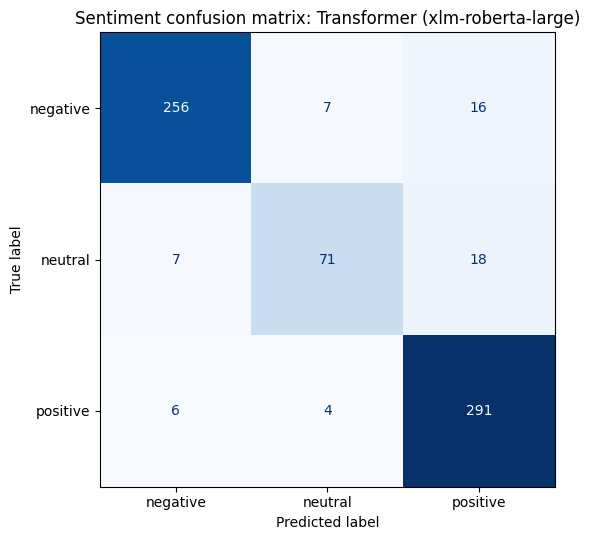

In [ ]:
import gc
import json
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay

if "final_results" not in globals() or final_results is None or len(final_results) == 0:
    comparison_candidates = [
        PROJECT_DIR / "final_results_all_models_with_rubert.csv",
        OUTPUT_DIR / "final_results_all_models.csv",
    ]
    for comparison_path in comparison_candidates:
        if comparison_path.exists():
            final_results = pd.read_csv(comparison_path)
            break
    else:
        raise FileNotFoundError("Run the training/evaluation cells first or provide final_results_all_models.csv.")

ok_results = final_results.copy()
if "status" in ok_results.columns:
    ok_results = ok_results[ok_results["status"].fillna("ok").eq("ok")]

if ok_results.empty:
    raise ValueError("No successful model rows were found in final_results.")

best_aspect_row = (
    ok_results.dropna(subset=["aspect_macro_f1"])
    .sort_values(["aspect_macro_f1", "aspect_micro_f1"], ascending=False)
    .iloc[0]
)
best_sentiment_row = (
    ok_results.dropna(subset=["sentiment_macro_f1"])
    .sort_values(["sentiment_macro_f1", "sentiment_accuracy"], ascending=False)
    .iloc[0]
)

best_aspect_model_name = best_aspect_row["model"]
best_sentiment_model_name = best_sentiment_row["model"]

print(f"Best aspect model: {best_aspect_model_name}")
print(f"Best sentiment model: {best_sentiment_model_name}")


def load_saved_metrics(model_name):
    """Return saved metric dictionaries for transformer models."""
    metric_path = None
    if model_name == f"Transformer ({CHECKPOINT})":
        metric_path = OUTPUT_DIR / "metrics.json"
    elif "RUBERT_CHECKPOINT" in globals() and model_name == f"Transformer ({RUBERT_CHECKPOINT})":
        metric_path = OUTPUT_DIR_RUBERT / "metrics.json"

    if metric_path is None or not metric_path.exists():
        return {}
    return json.loads(metric_path.read_text(encoding="utf-8"))


def get_metrics_for_model(model_name):
    """Collect metrics from notebook memory or from saved metrics.json files."""
    metrics = {}

    if model_name == "Rule-based":
        metrics["aspect"] = globals().get("rule_aspect")
        metrics["sentiment"] = globals().get("rule_sentiment")
    elif model_name == "TF-IDF + Logistic Regression":
        metrics["aspect"] = globals().get("lr_aspect_metrics")
        metrics["sentiment"] = globals().get("lr_sentiment_metrics")
    elif model_name == "TF-IDF + Linear SVM":
        metrics["aspect"] = globals().get("svm_aspect_metrics")
        metrics["sentiment"] = globals().get("svm_sentiment_metrics")
    elif model_name == f"Transformer ({CHECKPOINT})":
        metrics.update(globals().get("transformer_metrics", {}))
        if not metrics:
            metrics.update(load_saved_metrics(model_name))
    elif "RUBERT_CHECKPOINT" in globals() and model_name == f"Transformer ({RUBERT_CHECKPOINT})":
        metrics.update(globals().get("rubert_metrics", {}))
        if not metrics:
            metrics.update(load_saved_metrics(model_name))

    return {key: value for key, value in metrics.items() if value is not None}


best_aspect_metrics = get_metrics_for_model(best_aspect_model_name).get("aspect")
if best_aspect_metrics is None or "per_aspect" not in best_aspect_metrics:
    raise ValueError(f"Per-aspect metrics are unavailable for {best_aspect_model_name}.")

aspect_rows = []
for aspect_code in ASPECT_CODES:
    aspect_name = ASPECT_NAME_MAP[aspect_code]
    metric = best_aspect_metrics["per_aspect"].get(aspect_name, {})
    aspect_rows.append(
        {
            "aspect_code": aspect_code,
            "aspect_name": aspect_name,
            "precision": metric.get("precision", np.nan),
            "recall": metric.get("recall", np.nan),
            "f1": metric.get("f1-score", np.nan),
            "support": int(metric.get("support", 0)),
        }
    )

best_aspect_table = (
    pd.DataFrame(aspect_rows)
    .sort_values("f1", ascending=False, na_position="last")
    .reset_index(drop=True)
)
display(best_aspect_table)


def transformer_model_dir(model_name):
    if model_name == f"Transformer ({CHECKPOINT})":
        return OUTPUT_DIR
    if "RUBERT_CHECKPOINT" in globals() and model_name == f"Transformer ({RUBERT_CHECKPOINT})":
        return OUTPUT_DIR_RUBERT
    return None


def model_threshold(model_name, default=0.5):
    rows = ok_results[ok_results["model"].eq(model_name)]
    if rows.empty or "aspect_threshold" not in rows.columns:
        return default
    value = rows.iloc[0]["aspect_threshold"]
    return float(value) if pd.notna(value) else default


def saved_config_for(model_dir):
    model_dir = Path(model_dir)
    for filename in ["config.json", "model_config.json"]:
        config_path = model_dir / filename
        if config_path.exists():
            return json.loads(config_path.read_text(encoding="utf-8"))
    return {}


def training_config_for(model_dir):
    saved_config = saved_config_for(model_dir)
    return saved_config.get("training_config", asdict(train_cfg))


def predict_aspects_for_model(model_name):
    texts = test_reviews["text_clean"].tolist()
    y_true = test_reviews[ASPECT_CODES].values.astype(int)
    threshold = model_threshold(model_name)

    if model_name == "Rule-based":
        y_pred = rule_based_aspects(texts)
        return y_true, y_pred

    if model_name == "TF-IDF + Logistic Regression":
        probabilities = tfidf_lr_aspect.predict_proba(texts)
        y_pred = (probabilities >= threshold).astype(int)
        return y_true, y_pred

    if model_name == "TF-IDF + Linear SVM":
        scores = tfidf_svm_aspect.decision_function(texts)
        y_pred = (sigmoid(scores) >= threshold).astype(int)
        return y_true, y_pred

    model_dir = transformer_model_dir(model_name)
    if model_dir is None:
        raise ValueError(f"Prediction logic is not defined for {model_name}.")

    model_dir = Path(model_dir)
    cfg = training_config_for(model_dir)
    saved_config = saved_config_for(model_dir)
    if saved_config:
        threshold = float(saved_config.get("aspect_threshold", threshold))

    aspect_labels = [ASPECT_NAME_MAP[code] for code in ASPECT_CODES]
    tokenizer = AutoTokenizer.from_pretrained(model_dir / "aspect_model")
    model = load_model_from_checkpoint(
        model_dir / "aspect_model",
        num_labels=len(ASPECT_CODES),
        labels=aspect_labels,
        problem_type="multi_label_classification",
    )
    model.to(DEVICE)

    loader = make_loader(
        texts,
        y_true.astype(np.float32),
        tokenizer,
        int(cfg.get("max_length", train_cfg.max_length)),
        "aspect",
        int(cfg.get("batch_size", train_cfg.batch_size)),
        shuffle=False,
    )
    logits = predict_logits(model, loader, DEVICE, desc=f"Predict aspects ({model_name})")
    y_pred = (sigmoid(logits) >= threshold).astype(int)

    del model, tokenizer, loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return y_true, y_pred


def predict_sentiments_for_model(model_name):
    labels = [label for label in SENTIMENT_ORDER if label in set(sentiment_rows["sentiment"])]
    label2id = {label: idx for idx, label in enumerate(labels)}
    texts = test_sentiment["model_text"].tolist()
    y_true = test_sentiment["sentiment"].map(label2id).values.astype(int)

    if model_name == "Rule-based":
        y_pred = np.array([label2id.get(label, label2id.get("neutral", 0)) for label in rule_based_sentiment(texts)])
        return y_true, y_pred, labels

    if model_name == "TF-IDF + Logistic Regression":
        y_pred = tfidf_lr_sent.predict(texts)
        return y_true, y_pred, labels

    if model_name == "TF-IDF + Linear SVM":
        y_pred = tfidf_svm_sent.predict(texts)
        return y_true, y_pred, labels

    model_dir = transformer_model_dir(model_name)
    if model_dir is None:
        raise ValueError(f"Prediction logic is not defined for {model_name}.")

    model_dir = Path(model_dir)
    cfg = training_config_for(model_dir)
    tokenizer = AutoTokenizer.from_pretrained(model_dir / "sentiment_model")
    model = load_model_from_checkpoint(
        model_dir / "sentiment_model",
        num_labels=len(labels),
        labels=labels,
        problem_type=None,
    )
    model.to(DEVICE)

    loader = make_loader(
        texts,
        y_true,
        tokenizer,
        int(cfg.get("max_length", train_cfg.max_length)),
        "sentiment",
        int(cfg.get("batch_size", train_cfg.batch_size)),
        shuffle=False,
    )
    logits = predict_logits(model, loader, DEVICE, desc=f"Predict sentiments ({model_name})")
    y_pred = logits.argmax(axis=1)

    del model, tokenizer, loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return y_true, y_pred, labels


y_true_aspect, y_pred_aspect = predict_aspects_for_model(best_aspect_model_name)
y_true_sentiment, y_pred_sentiment, sentiment_labels = predict_sentiments_for_model(best_sentiment_model_name)

language_order = ["kz", "mixed", "ru"]
language_values = test_reviews["language"].fillna("unknown").astype(str).values
language_rows = []

for language in language_order + sorted(set(language_values) - set(language_order)):
    mask = language_values == language
    if not mask.any():
        continue
    language_rows.append(
        {
            "language": language,
            "task": "aspect_detection",
            "micro_f1": f1_score(y_true_aspect[mask], y_pred_aspect[mask], average="micro", zero_division=0),
            "macro_f1": f1_score(y_true_aspect[mask], y_pred_aspect[mask], average="macro", zero_division=0),
            "subset_accuracy": (y_true_aspect[mask] == y_pred_aspect[mask]).all(axis=1).mean(),
            "accuracy": np.nan,
            "weighted_f1": np.nan,
        }
    )

sentiment_languages = (
    test_sentiment[["review_id"]]
    .merge(test_reviews[["review_id", "language"]], on="review_id", how="left")["language"]
    .fillna("unknown")
    .astype(str)
    .values
)

for language in language_order + sorted(set(sentiment_languages) - set(language_order)):
    mask = sentiment_languages == language
    if not mask.any():
        continue
    language_rows.append(
        {
            "language": language,
            "task": "aspect_sentiment",
            "micro_f1": np.nan,
            "macro_f1": f1_score(y_true_sentiment[mask], y_pred_sentiment[mask], average="macro", zero_division=0),
            "subset_accuracy": np.nan,
            "accuracy": accuracy_score(y_true_sentiment[mask], y_pred_sentiment[mask]),
            "weighted_f1": f1_score(y_true_sentiment[mask], y_pred_sentiment[mask], average="weighted", zero_division=0),
        }
    )

language_metrics_table = pd.DataFrame(language_rows)
language_metrics_table["language"] = pd.Categorical(
    language_metrics_table["language"],
    categories=language_order + sorted(set(language_metrics_table["language"]) - set(language_order)),
    ordered=True,
)
language_metrics_table["task"] = pd.Categorical(
    language_metrics_table["task"],
    categories=["aspect_detection", "aspect_sentiment"],
    ordered=True,
)
language_metrics_table = language_metrics_table.sort_values(["task", "language"]).reset_index(drop=True)
display(language_metrics_table)

cm = confusion_matrix(y_true_sentiment, y_pred_sentiment, labels=list(range(len(sentiment_labels))))
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sentiment_labels).plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False,
)
ax.set_title(f"Sentiment confusion matrix: {best_sentiment_model_name}")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()

diagnostics_dir = PROJECT_DIR / "models" / "diagnostics"
diagnostics_dir.mkdir(parents=True, exist_ok=True)
best_aspect_table.to_csv(diagnostics_dir / "best_aspect_model_per_aspect_metrics.csv", index=False)
language_metrics_table.to_csv(diagnostics_dir / "best_models_language_metrics.csv", index=False)
fig.savefig(diagnostics_dir / "best_sentiment_confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()


## 22. Check Saved Artifacts


In [ ]:
expected_paths = [
    OUTPUT_DIR / "config.json",
    OUTPUT_DIR / "metrics.json",
    OUTPUT_DIR / "aspect_model",
    OUTPUT_DIR / "sentiment_model",
    OUTPUT_DIR / "aspect_model" / "model.safetensors",
    OUTPUT_DIR / "sentiment_model" / "model.safetensors",
    OUTPUT_DIR_RUBERT / "config.json",
    OUTPUT_DIR_RUBERT / "metrics.json",
    OUTPUT_DIR_RUBERT / "aspect_model",
    OUTPUT_DIR_RUBERT / "sentiment_model",
    OUTPUT_DIR_RUBERT / "aspect_model" / "model.safetensors",
    OUTPUT_DIR_RUBERT / "sentiment_model" / "model.safetensors",
]

artifact_table = pd.DataFrame([{"path": str(path), "exists": path.exists()} for path in expected_paths])
display(artifact_table)

,path,exists
0,c:\diploma1\models\final_model\config.json,True
1,c:\diploma1\models\final_model\metrics.json,True
2,c:\diploma1\models\final_model\aspect_model,True
3,c:\diploma1\models\final_model\sentiment_model,True
4,c:\diploma1\models\final_model\aspect_model\model.safetensors,True
5,c:\diploma1\models\final_model\sentiment_model\model.safetensors,True
6,c:\diploma1\models\final_model_rubert\config.json,False
7,c:\diploma1\models\final_model_rubert\metrics.json,False
8,c:\diploma1\models\final_model_rubert\aspect_model,True
9,c:\diploma1\models\final_model_rubert\sentiment_model,False


## 23. Saved-Model Loading Helpers for Streamlit


In [ ]:
@dataclass
class ABSAPipeline:
    model_dir: Path
    config: dict[str, Any]
    device: torch.device
    aspect_tokenizer: Any
    aspect_model: Any
    sentiment_tokenizer: Any
    sentiment_model: Any

def load_absa_pipeline(model_dir: str | Path = OUTPUT_DIR, device: str = "auto") -> ABSAPipeline:
    model_dir = Path(model_dir)
    config_path = model_dir / "config.json"
    if not config_path.exists():
        raise FileNotFoundError(f"Could not find {config_path}. Train and save the model first.")
    config = json.loads(config_path.read_text(encoding="utf-8"))
    selected_device = torch.device("cuda" if device == "auto" and torch.cuda.is_available() else ("cpu" if device == "auto" else device))

    aspect_dir = model_dir / config.get("aspect_model_dir", "aspect_model")
    sentiment_dir = model_dir / config.get("sentiment_model_dir", "sentiment_model")

    aspect_tokenizer = AutoTokenizer.from_pretrained(aspect_dir, use_fast=True)
    aspect_model = AutoModelForSequenceClassification.from_pretrained(aspect_dir).to(selected_device)
    aspect_model.eval()

    sentiment_tokenizer = AutoTokenizer.from_pretrained(sentiment_dir, use_fast=True)
    sentiment_model = AutoModelForSequenceClassification.from_pretrained(sentiment_dir).to(selected_device)
    sentiment_model.eval()

    return ABSAPipeline(model_dir, config, selected_device, aspect_tokenizer, aspect_model, sentiment_tokenizer, sentiment_model)

@torch.no_grad()
def predict_review(text: str, pipeline: ABSAPipeline, threshold: float | None = None):
    cleaned = clean_text(text, lowercase=True)
    if not cleaned:
        return {"text": text, "text_clean": cleaned, "detected_aspects": [], "predictions": []}

    threshold = float(threshold if threshold is not None else pipeline.config.get("aspect_threshold", 0.5))
    max_length = int(pipeline.config["training_config"]["max_length"])

    encoded = pipeline.aspect_tokenizer(cleaned, truncation=True, padding="max_length", max_length=max_length, return_tensors="pt")
    encoded = {key: value.to(pipeline.device) for key, value in encoded.items()}
    aspect_logits = pipeline.aspect_model(**encoded).logits.detach().cpu().numpy()[0]
    aspect_probs = sigmoid(aspect_logits)

    selected = np.where(aspect_probs >= threshold)[0].tolist()
    if pipeline.config.get("enforce_at_least_one_aspect", True) and not selected:
        selected = [int(aspect_probs.argmax())]

    predictions = []
    labels = pipeline.config["sentiment_labels"]
    for idx in selected:
        aspect = pipeline.config["aspect_schema"][idx]
        model_text = pipeline.config["sentiment_input_template"].format(aspect_name=aspect["name"], text=cleaned)
        sent_encoded = pipeline.sentiment_tokenizer(model_text, truncation=True, padding="max_length", max_length=max_length, return_tensors="pt")
        sent_encoded = {key: value.to(pipeline.device) for key, value in sent_encoded.items()}
        sent_logits = pipeline.sentiment_model(**sent_encoded).logits.detach().cpu().numpy()[0]
        sent_probs = softmax(sent_logits)
        sent_idx = int(sent_probs.argmax())
        predictions.append(
            {
                "aspect_code": aspect["code"],
                "aspect_name": aspect["name"],
                "aspect_probability": float(aspect_probs[idx]),
                "sentiment": labels[sent_idx],
                "sentiment_confidence": float(sent_probs[sent_idx]),
            }
        )

    predictions = sorted(predictions, key=lambda row: row["aspect_probability"], reverse=True)
    return {
        "text": text,
        "text_clean": cleaned,
        "aspect_threshold": threshold,
        "detected_aspects": [row["aspect_name"] for row in predictions],
        "predictions": predictions,
    }

## 24. Test Saved Model Prediction


In [ ]:
TEST_REVIEW = "Еда вкусная, персонал вежливый, но заказ ждали слишком долго."
MODEL_DIR_TO_TEST = OUTPUT_DIR

if (MODEL_DIR_TO_TEST / "config.json").exists():
    absa_pipeline = load_absa_pipeline(MODEL_DIR_TO_TEST, device="auto")
    prediction = predict_review(TEST_REVIEW, absa_pipeline)
    display(pd.DataFrame(prediction["predictions"]))
    print(json.dumps(prediction, indent=2, ensure_ascii=False))
else:
    print(f"Saved model was not found in {MODEL_DIR_TO_TEST}. Run transformer training cells first.")


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 3264.59it/s]


,aspect_code,aspect_name,aspect_probability,sentiment,sentiment_confidence
0,FQ,Food Quality,0.985158,positive,0.999919
1,WS,Wait/Speed,0.969260,negative,0.999786
2,SS,Staff Service,0.945616,positive,0.999888


{
  "text": "Еда вкусная, персонал вежливый, но заказ ждали слишком долго.",
  "text_clean": "еда вкусная, персонал вежливый, но заказ ждали слишком долго.",
  "aspect_threshold": 0.3,
  "detected_aspects": [
    "Food Quality",
    "Wait/Speed",
    "Staff Service"
  ],
  "predictions": [
    {
      "aspect_code": "FQ",
      "aspect_name": "Food Quality",
      "aspect_probability": 0.9851576089859009,
      "sentiment": "positive",
      "sentiment_confidence": 0.9999189376831055
    },
    {
      "aspect_code": "WS",
      "aspect_name": "Wait/Speed",
      "aspect_probability": 0.9692595601081848,
      "sentiment": "negative",
      "sentiment_confidence": 0.9997860789299011
    },
    {
      "aspect_code": "SS",
      "aspect_name": "Staff Service",
      "aspect_probability": 0.9456157088279724,
      "sentiment": "positive",
      "sentiment_confidence": 0.9998877048492432
    }
  ]
}


## 25. Streamlit Usage


After this notebook saves `models/final_model/`, the existing `streamlit_app.py` can load the model without retraining.

Run from PowerShell:

```powershell
.\.venv\Scripts\streamlit.exe run streamlit_app.py
```

If Streamlit is missing:

```powershell
.\.venv\Scripts\python.exe -m pip install streamlit
```


## 26. Notes About XLM-RoBERTa Large and RuBERT


`xlm-roberta-large` is large for a 6 GB RTX 3060 Laptop GPU. This notebook uses a memory-safe setup: small batch size, shorter sequence length, gradient accumulation, gradient checkpointing, and partial lower-layer freezing. This does not change the model architecture; it only makes fine-tuning fit into available memory.

`DeepPavlov/rubert-base-cased` is useful as a Russian-centric comparison. With recent Transformers versions, some checkpoints require `torch>=2.6` if they do not provide `safetensors` weights. If RuBERT fails with a `torch.load` security error, upgrade PyTorch in the same `.venv`.
